In [117]:
import geopandas as gpd
import matplotlib
matplotlib.use('Agg')  # Remove this line if running interactively
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.validation import make_valid
from shapely.geometry import MultiPolygon, Polygon
from shapely.affinity import translate

In [118]:
# ════════════════════════════════════════════════════════════════════
# STEP 0: Fix antimeridian wrapping (Russia, Fiji, etc.)
# ════════════════════════════════════════════════════════════════════

def unwrap_ring(coords):
    """Unwrap longitudes so consecutive vertices stay close to each other."""
    new_coords = []
    prev_x = None
    for x, y in coords:
        nx = x
        if prev_x is not None:
            while nx - prev_x > 180:
                nx -= 360
            while nx - prev_x < -180:
                nx += 360
        new_coords.append((nx, y))
        prev_x = nx
    return new_coords


def polygon_parts(geom):
    if geom.is_empty:
        return []
    if geom.geom_type == 'Polygon':
        return [geom]
    if geom.geom_type == 'MultiPolygon':
        return list(geom.geoms)
    if geom.geom_type == 'GeometryCollection':
        parts = []
        for g in geom.geoms:
            parts.extend(polygon_parts(g))
        return parts
    return []


def fix_geometry(geom):
    """Repair invalid polygons and correctly handle antimeridian-crossing shapes."""
    geom = make_valid(geom)
    out = []
    world_box = Polygon([(-180, -90), (180, -90), (180, 90), (-180, 90)])

    for poly in polygon_parts(geom):
        # Most polygons need no special treatment
        if (poly.bounds[2] - poly.bounds[0]) <= 180:
            out.append(poly)
            continue

        # Unwrap the polygon into a continuous longitude domain
        ext = unwrap_ring(list(poly.exterior.coords))
        holes = [unwrap_ring(list(r.coords)) for r in poly.interiors]
        unwrapped = make_valid(Polygon(ext, holes))

        for part in polygon_parts(unwrapped):
            # Intersect the part with the normal world extent, and also with
            # +/-360 shifted copies. This preserves pieces around the dateline
            # without creating long horizontal bands across the map.
            candidates = [
                part,
                translate(part, xoff=-360),
                translate(part, xoff=360),
            ]
            for cand in candidates:
                clipped = make_valid(cand.intersection(world_box))
                out.extend([p for p in polygon_parts(clipped) if p.area > 0])

    # Drop duplicates created by overlapping shifted copies
    dedup = []
    seen = set()
    for poly in out:
        key = poly.wkb
        if key not in seen:
            seen.add(key)
            dedup.append(poly)

    if not dedup:
        return geom
    if len(dedup) == 1:
        return dedup[0]
    return MultiPolygon(dedup)

In [119]:
# ════════════════════════════════════════════════════════════════════
# STEP 1: EDIT THIS — Define your country groups and colors
# ════════════════════════════════════════════════════════════════════

# Map: group_name -> list of country names (must match Natural Earth names)
# Run `print(sorted(world['name'].unique()))` to see all available names

# category_map = {
#     "English": [
#         "United States",
#         "Canada",
#         "American Samoa",
#         "Australia",
#         "Botswana",
#         "Cocos [Keeling] Islands",
#         "Cook Islands",
#         "Cameroon",
#         "Christmas Island",
#         "Eritrea",
#         "Fiji",
#         "Falkland Islands",
#         "Micronesia",
#         "United Kingdom",
#         "Guernsey",
#         "Ghana",
#         "Gibraltar",
#         "Gambia",
#         "South Georgia and the South Sandwich Islands",
#         "Guam",
#         "Guyana",
#         "Hong Kong",
#         "Heard Island and McDonald Islands",
#         "Ireland",
#         "Isle of Man",
#         "India",
#         "British Indian Ocean Territory",
#         "Jersey",
#         "Kenya",
#         "Kiribati",
#         "Liberia",
#         "Lesotho",
#         "Marshall Islands",
#         "Northern Mariana Islands",
#         "Malta",
#         "Mauritius",
#         "Malawi",
#         "Namibia",
#         "Norfolk Island",
#         "Nigeria",
#         "Nauru",
#         "Niue",
#         "New Zealand",
#         "Papua New Guinea",
#         "Philippines",
#         "Pakistan",
#         "Pitcairn Islands",
#         "Palau",
#         "Rwanda",
#         "Solomon Islands",
#         "Seychelles",
#         "Sudan",
#         "Singapore",
#         "Saint Helena",
#         "Sierra Leone",
#         "South Sudan",
#         "Swaziland",
#         "Tokelau",
#         "Tonga",
#         "Tuvalu",
#         "Tanzania",
#         "Uganda",
#         "U.S. Minor Outlying Islands",
#         "Vanuatu",
#         "Samoa",
#         "South Africa",
#         "Zambia",
#         "Zimbabwe"
#     ],
#     "Spanish": [
#         "Dominican Republic",
#         "Honduras",
#         "Costa Rica",
#         "Panama",
#         "El Salvador",
#         "Guatemala",
#         "Mexico",
#         "Nicaragua",
#         "Argentina",
#         "Bolivia",
#         "Chile",
#         "Colombia",
#         "Ecuador",
#         "Western Sahara",
#         "Spain",
#         "Equatorial Guinea",
#         "Guam",
#         "Peru",
#         "Paraguay",
#         "Uruguay",
#         "Venezuela"
#     ],
#     "French": [
#         "Canada",
#         "Belgium",
#         "Burkina Faso",
#         "Burundi",
#         "Benin",
#         "Democratic Republic of the Congo",
#         "Central African Republic",
#         "Republic of the Congo",
#         "Switzerland",
#         "Ivory Coast",
#         "Cameroon",
#         "Djibouti",
#         "France",
#         "Gabon",
#         "French Guiana",
#         "Guernsey",
#         "Guinea",
#         "Equatorial Guinea",
#         "Jersey",
#         "Comoros",
#         "Lebanon",
#         "Luxembourg",
#         "Monaco",
#         "Madagascar",
#         "Mali",
#         "New Caledonia",
#         "Niger",
#         "French Polynesia",
#         "R\u00e9union",
#         "Rwanda",
#         "Seychelles",
#         "Senegal",
#         "Chad",
#         "French Southern Territories",
#         "Togo",
#         "Vanuatu",
#         "Wallis and Futuna",
#         "Mayotte"
#     ],
#     "Catalan": [
#         "Andorra",
#         "Spain"
#     ],
#     "Arabic": [
#         "United Arab Emirates",
#         "Bahrain",
#         "Djibouti",
#         "Algeria",
#         "Egypt",
#         "Eritrea",
#         "Israel",
#         "Iraq",
#         "Jordan",
#         "Comoros",
#         "Kuwait",
#         "Lebanon",
#         "Libya",
#         "Morocco",
#         "Mauritania",
#         "Oman",
#         "Palestine",
#         "Qatar",
#         "Saudi Arabia",
#         "Sudan",
#         "Somalia",
#         "Syria",
#         "Chad",
#         "Tunisia",
#         "Yemen"
#     ],
#     "Pashto": [
#         "Afghanistan"
#     ],
#     "Uzbek": [
#         "Afghanistan",
#         "Uzbekistan"
#     ],
#     "Turkmen": [
#         "Afghanistan",
#         "Turkmenistan"
#     ],
#     "Albanian": [
#         "Albania",
#         "Montenegro",
#         "Kosovo"
#     ],
#     "Armenian": [
#         "Armenia",
#         "Cyprus"
#     ],
#     "Russian": [
#         "Armenia",
#         "Belarus",
#         "Kyrgyzstan",
#         "Kazakhstan",
#         "Russia",
#         "Tajikistan",
#         "Turkmenistan",
#         "Uzbekistan"
#     ],
#     "Portuguese": [
#         "Angola",
#         "Brazil",
#         "Cape Verde",
#         "Guinea-Bissau",
#         "Macao",
#         "Mozambique",
#         "Portugal",
#         "S\u00e3o Tom\u00e9 and Pr\u00edncipe",
#         "East Timor"
#     ],
#     "Guarani": [
#         "Argentina",
#         "Paraguay"
#     ],
#     "Samoan": [
#         "American Samoa",
#         "Samoa"
#     ],
#     "German": [
#         "Austria",
#         "Belgium",
#         "Switzerland",
#         "Germany",
#         "Liechtenstein",
#         "Luxembourg"
#     ],
#     "Swedish": [
#         "\u00c5land",
#         "Finland",
#         "Sweden"
#     ],
#     "Azerbaijani": [
#         "Azerbaijan"
#     ],
#     "Bosnian": [
#         "Bosnia and Herzegovina",
#         "Montenegro"
#     ],
#     "Croatian": [
#         "Bosnia and Herzegovina",
#         "Croatia",
#         "Montenegro"
#     ],
#     "Serbian": [
#         "Bosnia and Herzegovina",
#         "Montenegro",
#         "Serbia",
#         "Kosovo"
#     ],
#     "Bengali": [
#         "Bangladesh"
#     ],
#     "Dutch": [
#         "Belgium",
#         "Netherlands",
#         "Suriname"
#     ],
#     "Peul": [
#         "Burkina Faso",
#         "Guinea"
#     ],
#     "Bulgarian": [
#         "Bulgaria"
#     ],
#     "Kirundi": [
#         "Burundi"
#     ],
#     "Malay": [
#         "Brunei",
#         "Malaysia",
#         "Singapore"
#     ],
#     "Aymara": [
#         "Bolivia"
#     ],
#     "Quechua": [
#         "Bolivia"
#     ],
#     "Dzongkha": [
#         "Bhutan"
#     ],
#     "Norwegian": [
#         "Bouvet Island",
#         "Norway",
#         "Svalbard and Jan Mayen"
#     ],
#     "Norwegian Bokm\u00e5l": [
#         "Bouvet Island",
#         "Norway"
#     ],
#     "Norwegian Nynorsk": [
#         "Bouvet Island",
#         "Norway"
#     ],
#     "Tswana": [
#         "Botswana",
#         "South Africa"
#     ],
#     "Belarusian": [
#         "Belarus"
#     ],
#     "Lingala": [
#         "Democratic Republic of the Congo",
#         "Republic of the Congo"
#     ],
#     "Kongo": [
#         "Democratic Republic of the Congo"
#     ],
#     "Swahili": [
#         "Democratic Republic of the Congo",
#         "Kenya",
#         "Tanzania",
#         "Uganda"
#     ],
#     "Luba-Katanga": [
#         "Democratic Republic of the Congo"
#     ],
#     "Sango": [
#         "Central African Republic"
#     ],
#     "Italian": [
#         "Switzerland",
#         "Italy",
#         "San Marino",
#         "Vatican City"
#     ],
#     "Chinese": [
#         "China",
#         "Hong Kong",
#         "Macao",
#         "Singapore",
#         "Taiwan"
#     ],
#     "Greek": [
#         "Cyprus",
#         "Greece"
#     ],
#     "Turkish": [
#         "Cyprus",
#         "Turkey"
#     ],
#     "Czech": [
#         "Czech Republic"
#     ],
#     "Slovak": [
#         "Czech Republic",
#         "Slovakia"
#     ],
#     "Danish": [
#         "Denmark"
#     ],
#     "Estonian": [
#         "Estonia"
#     ],
#     "Tigrinya": [
#         "Eritrea"
#     ],
#     "Basque": [
#         "Spain"
#     ],
#     "Galician": [
#         "Spain"
#     ],
#     "Occitan": [
#         "Spain"
#     ],
#     "Amharic": [
#         "Ethiopia"
#     ],
#     "Finnish": [
#         "Finland"
#     ],
#     "Fijian": [
#         "Fiji"
#     ],
#     "Hindi": [
#         "Fiji",
#         "India"
#     ],
#     "Urdu": [
#         "Fiji",
#         "Pakistan"
#     ],
#     "Faroese": [
#         "Faroe Islands"
#     ],
#     "Georgian": [
#         "Georgia"
#     ],
#     "Chamorro": [
#         "Guam",
#         "Northern Mariana Islands"
#     ],
#     "Hungarian": [
#         "Hungary"
#     ],
#     "Indonesian": [
#         "Indonesia"
#     ],
#     "Irish": [
#         "Ireland"
#     ],
#     "Hebrew": [
#         "Israel"
#     ],
#     "Manx": [
#         "Isle of Man"
#     ],
#     "Kurdish": [
#         "Iraq"
#     ],
#     "Persian": [
#         "Iran"
#     ],
#     "Icelandic": [
#         "Iceland"
#     ],
#     "Japanese": [
#         "Japan"
#     ],
#     "Kyrgyz": [
#         "Kyrgyzstan"
#     ],
#     "Cambodian": [
#         "Cambodia"
#     ],
#     "Korean": [
#         "North Korea",
#         "South Korea"
#     ],
#     "Kazakh": [
#         "Kazakhstan"
#     ],
#     "Laotian": [
#         "Laos"
#     ],
#     "Sinhalese": [
#         "Sri Lanka"
#     ],
#     "Tamil": [
#         "Sri Lanka",
#         "Singapore"
#     ],
#     "Southern Sotho": [
#         "Lesotho",
#         "South Africa"
#     ],
#     "Lithuanian": [
#         "Lithuania"
#     ],
#     "Luxembourgish": [
#         "Luxembourg"
#     ],
#     "Latvian": [
#         "Latvia"
#     ],
#     "Romanian": [
#         "Moldova",
#         "Romania"
#     ],
#     "Malagasy": [
#         "Madagascar"
#     ],
#     "Marshallese": [
#         "Marshall Islands"
#     ],
#     "Macedonian": [
#         "North Macedonia"
#     ],
#     "Burmese": [
#         "Myanmar [Burma]"
#     ],
#     "Mongolian": [
#         "Mongolia"
#     ],
#     "Maltese": [
#         "Malta"
#     ],
#     "Divehi": [
#         "Maldives"
#     ],
#     "Chichewa": [
#         "Malawi"
#     ],
#     "Afrikaans": [
#         "Namibia",
#         "South Africa"
#     ],
#     "Nepali": [
#         "Nepal"
#     ],
#     "Nauruan": [
#         "Nauru"
#     ],
#     "Maori": [
#         "New Zealand"
#     ],
#     "Polish": [
#         "Poland"
#     ],
#     "Rwandi": [
#         "Rwanda"
#     ],
#     "Slovenian": [
#         "Slovenia"
#     ],
#     "Somalia": [
#         "Somalia"
#     ],
#     "Swati": [
#         "Swaziland",
#         "South Africa"
#     ],
#     "Thai": [
#         "Thailand"
#     ],
#     "Tajik": [
#         "Tajikistan"
#     ],
#     "Tonga": [
#         "Tonga"
#     ],
#     "Ukrainian": [
#         "Ukraine"
#     ],
#     "Latin": [
#         "Vatican City"
#     ],
#     "Vietnamese": [
#         "Vietnam"
#     ],
#     "Bislama": [
#         "Vanuatu"
#     ],
#     "South Ndebele": [
#         "South Africa"
#     ],
#     "Tsonga": [
#         "South Africa"
#     ],
#     "Venda": [
#         "South Africa"
#     ],
#     "Xhosa": [
#         "South Africa"
#     ],
#     "Zulu": [
#         "South Africa"
#     ],
#     "Shona": [
#         "Zimbabwe"
#     ],
#     "North Ndebele": [
#         "Zimbabwe"
#     ]
# }

category_map = {
    'English': [
        'United States of America', 'Canada', 'United Kingdom', 'Australia',
        'New Zealand', 'Ireland', 'South Africa', 'Jamaica', 'Barbados', 'Trinidad and Tobago',
        'Bahamas', 'Antigua and Barb.', 'Saint Lucia', 'Dominica', 'Grenada', 'Singapore'
    ],
    
    'Spanish': [
        'Spain', 'Argentina', 'Bolivia', 'Chile', 'Colombia', 'Costa Rica', 'Cuba', 
        'Dominican Rep.', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'Mexico', 
        'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Uruguay', 'Eq. Guinea', 'Venezuela'
    ],

"Arabic": [
        "United Arab Emirates",
        "Bahrain",
        "Djibouti",
        "Algeria",
        "Egypt",
        "Eritrea",
        "Israel",
        "Iraq",
        "Jordan",
        "Comoros",
        "Kuwait",
        "Lebanon",
        "Libya",
        "Morocco",
        "Mauritania",
        "Oman",
        "Palestine",
        "Qatar",
        "Saudi Arabia",
        "Sudan",
        "Somalia",
        "Syria",
        "Chad",
        "Tunisia",
        "Yemen"
    ],

    'Chinese': [
        'China', 'Taiwan', 'Hong Kong', 'Macau'
    ],
    
    'Japanese': ['Japan'],
    
    # stay commented out 
    # 'German': [
    #     'Germany', 'Austria', 'Switzerland', 'Liechtenstein'
    # ],

    "Polish": [
        "Poland"
    ],

        "Dutch": [
        "Belgium",
        "Netherlands",
        "Suriname"
    ],

            "Kazakh": [
        "Kazakhstan"
    ],
    
    'Russian': ['Russia', 'Belarus'],

    "Korean": [
        "North Korea",
        "South Korea"
    ],

    'Portuguese': [
        'Brazil', 'Portugal', 'Angola', 'Mozambique', 'Cabo Verde', 'Guinea-Bissau', 'São Tomé and Principe', 'Timor-Leste'
    ],
    
# keep commented out    
# 'French': [
#         'France', 'Monaco', 'Benin', 'Burkina Faso', 'Burundi', 'Central African Rep.', 
#         'Chad', 'Congo', 'Dem. Rep. Congo', "Côte d'Ivoire", 'Djibouti', 'Gabon', 'Guinea', 'Mali', 
#         'Niger', 'Rwanda', 'Senegal', 'Togo', 'Haiti', 'Vanuatu'
#     ],
    
# keep commented out    
# 'Norwegian': ['Norway'],

}

# Colors for each group
colors = {
    'English':    '#ADD8E6',  # Light Blue
    'Spanish':    '#FF0000',  # Bright Red
    'Arabic':    '#B19CD9',  # Light Purple
    'Chinese':   '#FFFF00',  # Bright Yellow
    'Japanese':     '#ED7D31',  # Orange
    'Polish':    '#FFF2CC',  # Light Yellow
    'Dutch':     '#90EE90',  # Light Green
    'Kazakh':  '#8B4513',  # Brown
    'Russian': '#0B6E4F',
    'Korean': '#6A3D9A', 
    'Portuguese': '#FF66B4',  # Pink
}

category_map_copy = {}
for language, country_lst in category_map.items():
    if language in colors:
        category_map_copy[language] = country_lst

category_map = category_map_copy

In [120]:
category_map

{'English': ['United States of America',
  'Canada',
  'United Kingdom',
  'Australia',
  'New Zealand',
  'Ireland',
  'South Africa',
  'Jamaica',
  'Barbados',
  'Trinidad and Tobago',
  'Bahamas',
  'Antigua and Barb.',
  'Saint Lucia',
  'Dominica',
  'Grenada',
  'Singapore'],
 'Spanish': ['Spain',
  'Argentina',
  'Bolivia',
  'Chile',
  'Colombia',
  'Costa Rica',
  'Cuba',
  'Dominican Rep.',
  'Ecuador',
  'El Salvador',
  'Guatemala',
  'Honduras',
  'Mexico',
  'Nicaragua',
  'Panama',
  'Paraguay',
  'Peru',
  'Uruguay',
  'Eq. Guinea',
  'Venezuela'],
 'Arabic': ['United Arab Emirates',
  'Bahrain',
  'Djibouti',
  'Algeria',
  'Egypt',
  'Eritrea',
  'Israel',
  'Iraq',
  'Jordan',
  'Comoros',
  'Kuwait',
  'Lebanon',
  'Libya',
  'Morocco',
  'Mauritania',
  'Oman',
  'Palestine',
  'Qatar',
  'Saudi Arabia',
  'Sudan',
  'Somalia',
  'Syria',
  'Chad',
  'Tunisia',
  'Yemen'],
 'Chinese': ['China', 'Taiwan', 'Hong Kong', 'Macau'],
 'Japanese': ['Japan'],
 'Polish': ['

In [121]:
# ════════════════════════════════════════════════════════════════════
# STEP 2: EDIT THIS — Country labels (name -> display_label, x, y, fontsize)
# ════════════════════════════════════════════════════════════════════

label_map = {
    # 'United States of America': ('UNITED STATES', -100, 40, 7.5),
    # 'Canada':    ('CANADA', -100, 58, 7.5),
    # 'Brazil':    ('BRAZIL', -53, -10, 8.5),
    # 'Russia':    ('RUSSIA', 90, 62, 8.5),
    # 'China':     ('CHINA', 103, 36, 8.5),
    # 'Australia': ('AUSTRALIA', 134, -25, 7.5),
    # # 'India':     ('INDIA', 80, 22, 6),
    # 'Argentina': ('ARGENTINA', -65, -35, 5.5),
    # 'Mexico':    ('MEXICO', -103, 24, 5),
    # 'Japan':     ('JAPAN', 143, 37, 5),
    # 'France':    ('FRANCE', 2.5, 47, 4.5),
    # 'Germany':   ('GERMANY', 10, 51, 4.5),
    # 'Spain':     ('SPAIN', -3.5, 40, 4.5),
    # 'United Kingdom': ('UK', -3, 55, 4),
    # 'Norway':    ('NORWAY', 12, 64, 4.5),
    # 'Portugal':  ('PORTUGAL', -8, 39.5, 3.5),
    # 'New Zealand': ('NEW\nZEALAND', 173, -42, 3.5),
    # 'Colombia':  ('COLOMBIA', -73, 4, 4.5),
    # 'Peru':      ('PERU', -75, -10, 5),
    # 'Chile':     ('CHILE', -71, -30, 4),
    # 'Bolivia':   ('BOLIVIA', -65, -17, 4),
    # 'Venezuela': ('VENEZUELA', -66, 7.5, 4),
    # 'Nigeria':   ('NIGERIA', 8, 9, 4.5),
    # 'South Africa': ('SOUTH\nAFRICA', 25, -30, 4),
    # 'Mali':      ('MALI', -2, 17, 4.5),
    # 'Niger':     ('NIGER', 9, 17, 4.5),
    # 'Chad':      ('CHAD', 19, 15, 4.5),
    # 'Dem. Rep. Congo': ('DR CONGO', 24, -3, 4),
    # 'Angola':    ('ANGOLA', 18, -12, 4.5),
    # 'Cuba':      ('CUBA', -79, 22, 3.5),
    # # 'Belarus':   ('BELARUS', 28, 53.5, 3.5),
    # # 'Kazakhstan': ('KAZAKHSTAN', 67, 48, 5),
}

In [122]:
# ════════════════════════════════════════════════════════════════════
# STEP 3: Load data, build map (usually no edits needed below)
# ════════════════════════════════════════════════════════════════════

GEOJSON_PATH = 'countries_10m.geojson'   # path to your converted geojson
OUTPUT_PATH  = 'world_map.svg'
DPI          = 1200
FIGSIZE      = (22, 11)

# Load and fix geometries
world = gpd.read_file(GEOJSON_PATH)
world['geometry'] = world['geometry'].apply(fix_geometry)
world = world[~world['geometry'].is_empty]
world = world[world['name'] != 'Antarctica']

# Assign categories
c2cat = {}
for cat, countries in category_map.items():
    for c in countries:
        c2cat[c] = cat
world['category'] = world['name'].map(c2cat)

# ── Draw ──
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

# Gray background
world[world['category'].isna()].plot(
    ax=ax, color='#F0F0F0', edgecolor='#AAAAAA', linewidth=0.3)

# Colored groups
for cat_name, color in colors.items():
    print(f"Drawing category '{cat_name}'...")
    subset = world[world['category'] == cat_name]
    if len(subset) == 0:
        continue

    subset.plot(ax=ax, color=color, edgecolor='#333333', linewidth=0.5)

# Labels
for name, (label, lx, ly, fs) in label_map.items():
    ax.text(lx, ly, label, fontsize=fs, fontweight='bold',
            ha='center', va='center', color='#222222', alpha=0.7,
            fontfamily='sans-serif')

# dataset_count = [34, 16, 14, 5, 4, 4, 3, 3, 3]
dataset_count = [14, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1]

# Legend
legend_items = [
    mpatches.Patch(facecolor=colors[cat], edgecolor='#333333', linewidth=0.5,
                   label=f'{cat} ({count})')
    for cat, count in zip(colors.keys(), dataset_count)
]
ax.legend(handles=legend_items, loc='lower left', fontsize=20,
          frameon=True, framealpha=0.95, edgecolor='none',
          bbox_to_anchor=(0.005, 0.02), handlelength=1.8,
          handleheight=1.3, borderpad=1.0, labelspacing=0.6)

ax.set_xlim(-180, 180)
ax.set_ylim(-58, 85)
ax.set_facecolor('white')
ax.set_axis_off()
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.5)
plt.savefig(OUTPUT_PATH, dpi=DPI, bbox_inches='tight',
            facecolor='white', pad_inches=0.1)
plt.close()
print(f"Saved to {OUTPUT_PATH}")

Drawing category 'English'...
Drawing category 'Spanish'...
Drawing category 'Arabic'...
Drawing category 'Chinese'...
Drawing category 'Japanese'...
Drawing category 'Polish'...
Drawing category 'Dutch'...
Drawing category 'Kazakh'...
Drawing category 'Russian'...
Drawing category 'Korean'...
Drawing category 'Portuguese'...
Saved to world_map.svg


In [123]:
c2cat

{'United States of America': 'English',
 'Canada': 'English',
 'United Kingdom': 'English',
 'Australia': 'English',
 'New Zealand': 'English',
 'Ireland': 'English',
 'South Africa': 'English',
 'Jamaica': 'English',
 'Barbados': 'English',
 'Trinidad and Tobago': 'English',
 'Bahamas': 'English',
 'Antigua and Barb.': 'English',
 'Saint Lucia': 'English',
 'Dominica': 'English',
 'Grenada': 'English',
 'Singapore': 'English',
 'Spain': 'Spanish',
 'Argentina': 'Spanish',
 'Bolivia': 'Spanish',
 'Chile': 'Spanish',
 'Colombia': 'Spanish',
 'Costa Rica': 'Spanish',
 'Cuba': 'Spanish',
 'Dominican Rep.': 'Spanish',
 'Ecuador': 'Spanish',
 'El Salvador': 'Spanish',
 'Guatemala': 'Spanish',
 'Honduras': 'Spanish',
 'Mexico': 'Spanish',
 'Nicaragua': 'Spanish',
 'Panama': 'Spanish',
 'Paraguay': 'Spanish',
 'Peru': 'Spanish',
 'Uruguay': 'Spanish',
 'Eq. Guinea': 'Spanish',
 'Venezuela': 'Spanish',
 'United Arab Emirates': 'Arabic',
 'Bahrain': 'Arabic',
 'Djibouti': 'Arabic',
 'Algeria': 

# Structure of the data follows something like this.

world... 

world["id"]: some natural number, used as unique identifier in this case --> ISO-3166-1 numeric country codes

world["name"]: some natural number, used as unique identifier in this case --> name of country

world["geometry"]: some natural number, used as unique identifier in this case --> a very long vector of the type <class 'shapely.geometry.polygon.Polygon'>... probably just encoding information on the shapes of the countries on the map.

Probably don't even need to touch these parts of the dictionary above.

world["category"]: some natural number, used as unique identifier in this case --> a language, or a none value.

In [124]:
for k, v in world.items(): 
    print(k)

id
name
geometry
category


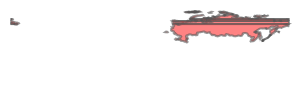

In [125]:
world["geometry"][75]

In [126]:
for k, v in world["name"].items(): 
    if "Russia" in v: 
        print(k, v)

75 Russia
